In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import torch
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader

In [3]:
!ls /content

drive  sample_data


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Semicon_Hackathon/train.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset Extracted")

✅ Dataset Extracted


In [8]:
import os

print(os.listdir("/content/dataset"))
print(os.listdir("/content/dataset/train"))

['train', '__MACOSX']
['GT', '.DS_Store', 'NoisyLR']


In [9]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class SEMDataset(Dataset):

    def __init__(self, root):

        self.gt_path = os.path.join(root, "GT")
        self.lr_path = os.path.join(root, "NoisyLR")

        self.files = sorted([
            f for f in os.listdir(self.gt_path)
            if f.endswith(".npy")
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        gt = np.load(os.path.join(self.gt_path, filename)).astype(np.float32)
        lr = np.load(os.path.join(self.lr_path, filename)).astype(np.float32)

        gt = torch.from_numpy(gt).unsqueeze(0)
        lr = torch.from_numpy(lr).unsqueeze(0)

        return lr, gt

In [10]:
dataset = SEMDataset("/content/dataset/train")

print("Total Images :", len(dataset))

Total Images : 3200


In [11]:
lr, gt = dataset[0]

print(lr.shape)
print(gt.shape)

print(lr.dtype)
print(gt.dtype)

torch.Size([1, 128, 128])
torch.Size([1, 256, 256])
torch.float32
torch.float32


In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("DataLoader Ready")

DataLoader Ready


In [13]:
lr_batch, gt_batch = next(iter(train_loader))

print("LR Batch :", lr_batch.shape)
print("GT Batch :", gt_batch.shape)

LR Batch : torch.Size([16, 1, 128, 128])
GT Batch : torch.Size([16, 1, 256, 256])


In [14]:
!pip -q install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 39.7 MB/s eta 0:00:00


In [15]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print(torch.cuda.get_device_name(0))

cuda
Tesla T4


In [17]:
import torch
import torch.nn as nn

class SRCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        self.conv1 = nn.Conv2d(1,64,9,padding=4)
        self.conv2 = nn.Conv2d(64,32,5,padding=2)
        self.conv3 = nn.Conv2d(32,1,5,padding=2)

        self.relu = nn.ReLU(inplace=True)

    def forward(self,x):

        x=self.upsample(x)

        x=self.relu(self.conv1(x))
        x=self.relu(self.conv2(x))
        x=self.conv3(x)

        return x

In [18]:
model=SRCNN().to(device)

print(model)

SRCNN(
  (upsample): Upsample(scale_factor=2.0, mode='bicubic')
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU(inplace=True)
)


In [19]:
import torch.optim as optim

criterion=nn.MSELoss()

optimizer=optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [20]:
lr_batch,gt_batch=next(iter(train_loader))

lr_batch=lr_batch.to(device)
gt_batch=gt_batch.to(device)

output=model(lr_batch)

print(output.shape)
print(gt_batch.shape)

torch.Size([16, 1, 256, 256])
torch.Size([16, 1, 256, 256])


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import zipfile

zip_path = "/content/drive/MyDrive/train.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/train.zip'

In [23]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [24]:
class SEMDataset(Dataset):

    def __init__(self, root):
        self.gt_path = os.path.join(root, "GT")
        self.lr_path = os.path.join(root, "NoisyLR")

        self.files = sorted(
            [f for f in os.listdir(self.gt_path) if f.endswith(".npy")]
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]

        gt = np.load(os.path.join(self.gt_path, file)).astype(np.float32)
        lr = np.load(os.path.join(self.lr_path, file)).astype(np.float32)

        gt = torch.from_numpy(gt).unsqueeze(0)
        lr = torch.from_numpy(lr).unsqueeze(0)

        return lr, gt

In [25]:
dataset = SEMDataset("/content/dataset/train")

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(len(dataset))

3200


In [26]:
lr_batch, gt_batch = next(iter(train_loader))

print(lr_batch.shape)
print(gt_batch.shape)

torch.Size([16, 1, 128, 128])
torch.Size([16, 1, 256, 256])


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [28]:
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode='bicubic',
            align_corners=False
        )

        self.net = nn.Sequential(
            nn.Conv2d(1,64,9,padding=4),
            nn.ReLU(True),

            nn.Conv2d(64,32,5,padding=2),
            nn.ReLU(True),

            nn.Conv2d(32,1,5,padding=2)
        )

    def forward(self,x):
        x=self.upsample(x)
        x=self.net(x)
        return x

In [29]:
model=SRCNN().to(device)

criterion=nn.MSELoss()

optimizer=torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [30]:
lr_batch,gt_batch=next(iter(train_loader))

lr_batch=lr_batch.to(device)
gt_batch=gt_batch.to(device)

output=model(lr_batch)

print(output.shape)
print(gt_batch.shape)

torch.Size([16, 1, 256, 256])
torch.Size([16, 1, 256, 256])


In [31]:
loss=criterion(output,gt_batch)

print(loss.item())

0.3644334673881531


In [32]:
epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for lr, gt in train_loader:

        lr = lr.to(device)
        gt = gt.to(device)

        optimizer.zero_grad()

        pred = model(lr)

        loss = criterion(pred, gt)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}  Loss : {running_loss/len(train_loader):.6f}")

Epoch 1/10  Loss : 0.017704
Epoch 2/10  Loss : 0.003873
Epoch 3/10  Loss : 0.003571
Epoch 4/10  Loss : 0.003504
Epoch 5/10  Loss : 0.003466
Epoch 6/10  Loss : 0.003439
Epoch 7/10  Loss : 0.003414
Epoch 8/10  Loss : 0.003407
Epoch 9/10  Loss : 0.003385
Epoch 10/10  Loss : 0.003374


In [33]:
torch.save(model.state_dict(),"SRCNN_Baseline.pth")

print("Model Saved")

Model Saved


In [34]:
!pip -q install torchmetrics

In [35]:
from torchmetrics.image import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

In [36]:
model.eval()

total_psnr = 0
total_ssim = 0
count = 0

with torch.no_grad():

    for lr, gt in train_loader:

        lr = lr.to(device)
        gt = gt.to(device)

        pred = model(lr)

        total_psnr += psnr_metric(pred, gt).item()
        total_ssim += ssim_metric(pred, gt).item()

        count += 1

print("Average PSNR :", total_psnr / count)
print("Average SSIM :", total_ssim / count)

Average PSNR : 25.091525039672852
Average SSIM : 0.7119816556572914


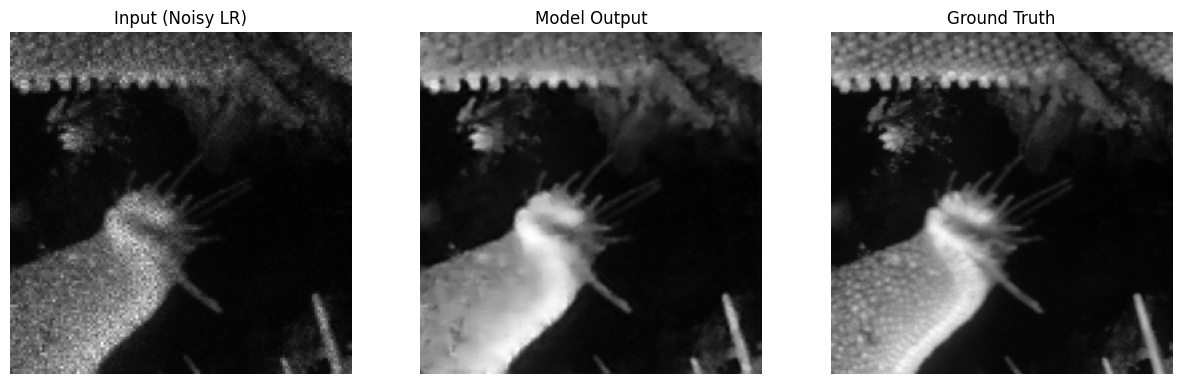

In [37]:
import matplotlib.pyplot as plt

model.eval()

lr, gt = dataset[0]

with torch.no_grad():
    pred = model(lr.unsqueeze(0).to(device)).cpu().squeeze().numpy()

lr = lr.squeeze().numpy()
gt = gt.squeeze().numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(lr, cmap="gray")
plt.title("Input (Noisy LR)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred, cmap="gray")
plt.title("Model Output")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.show()

In [38]:
plt.imsave("prediction.png", pred, cmap="gray")
print("Saved prediction.png")

Saved prediction.png


In [39]:
print(len(dataset))

3200


In [40]:
!ping -c 2 github.com

/bin/bash: line 1: ping: command not found


In [41]:
!git --version


git version 2.34.1


In [42]:
!git clone https://github.com/sanghyun-son/EDSR-PyTorch.git

Cloning into 'EDSR-PyTorch'...
remote: Enumerating objects: 806, done.
remote: Total 806 (delta 0), reused 0 (delta 0), pack-reused 806 (from 1)
Receiving objects: 100% (806/806), 63.09 MiB | 19.98 MiB/s, done.
Resolving deltas: 100% (516/516), done.


In [43]:
!pip -q install fastapi uvicorn pyngrok nest_asyncio python-multipart

In [44]:
torch.save(model.state_dict(), "model.pth")

In [45]:
!cp model.pth /content/drive/MyDrive/

In [46]:
from fastapi import FastAPI, UploadFile, File
import uvicorn
import nest_asyncio

app = FastAPI()

@app.get("/")
def home():
    return {"message":"SEMICON AI Backend Running"}

In [47]:
import torch
import torch.nn as nn
import numpy as np

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")